# Empirical Evaluation of K-Means Initialization

This notebook evaluates how the initialization strategy and the number of centroid initializations (`n_init`) affect K-Means clustering quality, stability, and computational cost.

The experiment uses a synthetic two-dimensional dataset with nine well-separated Gaussian clusters arranged in a 3 × 3 grid. It compares:

- `KMeans` with `k-means++` initialization
- `KMeans` with random initialization
- `MiniBatchKMeans` with `k-means++` initialization
- `MiniBatchKMeans` with random initialization
- `n_init` values of `1, 5, 10, 15` and `20`

The evaluation uses inertia, Adjusted Rand Index (ARI), fitting time, and variability across five repeated runs.

Plots are saved in:
```
root_folder/plots/emp_eval_init/
```
Numerical results are saved in:
```
root_folder/results/emp_eval_init/
```

### Import Required Libraries

Import the libraries required for path handling, timing, numerical operations, data tables, clustering, evaluation, and visualization.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import check_random_state, shuffle

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

##### Explanation :
The required libraries are now available. The pandas display settings are expanded so that result tables can be viewed without hiding important columns.

### Define the Project Folders

Identify the project root from the notebook location and create the required plot and result folders.

In [2]:
def find_project_root(start_path):
    """
    Find the main project folder containing:
    data/, notebooks/, plots/, and results/.
    """
    current_path = Path(start_path).resolve()

    for folder in [current_path, *current_path.parents]:
        required_folders = [
            folder / "data",
            folder / "notebooks",
            folder / "plots",
            folder / "results",
        ]

        if all(path.is_dir() for path in required_folders):
            return folder

    raise FileNotFoundError(
        "The project root could not be found. "
        "Make sure data, notebooks, plots, and results folders exist."
    )


# Find the main project folder
CURRENT_DIR = Path.cwd().resolve()
ROOT_DIR = find_project_root(CURRENT_DIR)

# Correct notebook folder and file
NOTEBOOK_DIR = ROOT_DIR / "notebooks" / "module_2"
NOTEBOOK_PATH = NOTEBOOK_DIR / "05_emp_eval_init.ipynb"

# Output folders for this notebook
PLOT_DIR = ROOT_DIR / "plots" / "emp_eval_init"
RESULTS_DIR = ROOT_DIR / "results" / "emp_eval_init"

# Create output folders if they do not exist
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("PROJECT FOLDER PATHS")
print("=" * 100)
print(f"Current folder  : {CURRENT_DIR}")
print(f"Root folder     : {ROOT_DIR}")
print(f"Notebook folder : {NOTEBOOK_DIR}")
print(f"Notebook file   : {NOTEBOOK_PATH}")
print(f"Plot folder     : {PLOT_DIR}")
print(f"Results folder  : {RESULTS_DIR}")
print("=" * 100)

print("\nPATH CHECK")
print("-" * 100)
print(f"Root folder exists     : {ROOT_DIR.exists()}")
print(f"Notebook folder exists : {NOTEBOOK_DIR.exists()}")
print(f"Notebook file exists   : {NOTEBOOK_PATH.exists()}")
print(f"Plot folder exists     : {PLOT_DIR.exists()}")
print(f"Results folder exists  : {RESULTS_DIR.exists()}")

PROJECT FOLDER PATHS
Current folder  : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Root folder     : C:\Users\samsa\Documents\Capstone Project\Project
Notebook folder : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Notebook file   : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\05_emp_eval_init.ipynb
Plot folder     : C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init
Results folder  : C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init

PATH CHECK
----------------------------------------------------------------------------------------------------
Root folder exists     : True
Notebook folder exists : True
Notebook file exists   : True
Plot folder exists     : True
Results folder exists  : True


##### Explanation :
This code detects whether the notebook is currently running inside the notebooks folder. It then identifies the project root folder and creates the following output directories if they do not already exist:
```
root_folder/plots/emp_eval_init/
root_folder/results/emp_eval_init/
```

### Set the Experiment Parameters

Define the random seed, number of repeated runs, tested n_init values, synthetic dataset settings, and plot resolution.

In [3]:
RANDOM_SEED = 0

N_RUNS = 5

N_INIT_RANGE = np.array(
    [1, 5, 10, 15, 20],
    dtype=int,
)

N_SAMPLES_PER_CENTER = 100
GRID_SIZE = 3
CLUSTER_STD = 0.1

N_CLUSTERS = GRID_SIZE ** 2

FIG_DPI = 300

print("=" * 80)
print("EXPERIMENT CONFIGURATION")
print("=" * 80)
print(f"Random seed         : {RANDOM_SEED}")
print(f"Repeated runs       : {N_RUNS}")
print(f"n_init values       : {N_INIT_RANGE.tolist()}")
print(f"Grid size           : {GRID_SIZE} × {GRID_SIZE}")
print(f"Number of clusters  : {N_CLUSTERS}")
print(f"Samples per cluster : {N_SAMPLES_PER_CENTER}")
print(f"Total samples       : {N_CLUSTERS * N_SAMPLES_PER_CENTER}")
print(f"Cluster noise       : {CLUSTER_STD}")
print("=" * 80)

EXPERIMENT CONFIGURATION
Random seed         : 0
Repeated runs       : 5
n_init values       : [1, 5, 10, 15, 20]
Grid size           : 3 × 3
Number of clusters  : 9
Samples per cluster : 100
Total samples       : 900
Cluster noise       : 0.1


##### Explanation :
The experiment contains nine clusters because a `3 × 3` grid is used. Each cluster contains `100` observations, resulting in a total of `900` observations.

Every estimator configuration is evaluated on five independently generated datasets for each tested `n_init` value.

The `n_init` parameter determines how many independent centroid initialization attempts are performed before the best clustering solution is selected.

### Create the Synthetic Dataset Function

Create a reusable function that generates nine compact Gaussian clusters arranged in a regular `3 × 3` grid.

In [4]:
def make_data(
    random_state,
    n_samples_per_center=N_SAMPLES_PER_CENTER,
    grid_size=GRID_SIZE,
    scale=CLUSTER_STD,
):
    """
    Generate well-separated Gaussian clusters arranged in a grid.
    """

    rng = check_random_state(random_state)

    centers = np.array(
        [
            [row, column]
            for row in range(grid_size)
            for column in range(grid_size)
        ],
        dtype=float,
    )

    n_clusters, n_features = centers.shape

    noise = rng.normal(
        loc=0.0,
        scale=scale,
        size=(n_samples_per_center, n_features),
    )

    X = np.concatenate(
        [
            center + noise
            for center in centers
        ],
        axis=0,
    )

    y = np.repeat(
        np.arange(n_clusters),
        n_samples_per_center,
    )

    X, y = shuffle(
        X,
        y,
        random_state=rng,
    )

    return X, y, centers

##### Explanation :
The function creates nine true centers positioned at the following grid locations:
```
(0, 0), (0, 1), (0, 2)
(1, 0), (1, 1), (1, 2)
(2, 0), (2, 1), (2, 2)
```
Gaussian noise is added around each center to create compact synthetic clusters.

The function returns:

- `X`: the two-dimensional feature matrix
- `y`: the known true cluster labels
- `centers`: the true cluster-center coordinates

The true labels are used only to evaluate the clustering results with the Adjusted Rand Index.

### Generate and Inspect an Example Dataset

Generate one reproducible dataset, verify its dimensions, and display the first ten observations.

In [5]:
X_demo, y_demo, true_centers = make_data(
    random_state=RANDOM_SEED
)

print("=" * 80)
print("SYNTHETIC DATASET")
print("=" * 80)
print(f"Feature matrix shape : {X_demo.shape}")
print(f"Label array shape    : {y_demo.shape}")
print(f"True center shape    : {true_centers.shape}")
print(f"Number of clusters   : {len(np.unique(y_demo))}")
print("=" * 80)

data_preview = pd.DataFrame(
    {
        "Feature_1": X_demo[:, 0],
        "Feature_2": X_demo[:, 1],
        "True_Cluster": y_demo,
    }
)

display(data_preview.head(10))

SYNTHETIC DATASET
Feature matrix shape : (900, 2)
Label array shape    : (900,)
True center shape    : (9, 2)
Number of clusters   : 9


,Feature_1,Feature_2,True_Cluster
0,-0.064362,1.777660,2
1,-0.161390,0.978726,1
2,0.118803,1.031694,1
3,0.882688,2.194362,5
4,0.123029,0.120238,0
5,-0.125280,0.077749,0
6,-0.170627,1.195078,1
7,2.020827,2.097664,8
8,0.936415,1.067643,4
9,2.117878,0.982008,7


##### Explanation :
The expected feature matrix shape is:
```
(900, 2)
```
This means that the dataset contains `900` observations and two features.

The label array contains `900` known cluster labels, and the true-center matrix contains nine center coordinates.

The displayed table allows us to inspect the first ten observations before applying K-Means clustering.

### Visualize the Synthetic Dataset

Plot the observations using their known cluster labels and mark the true centers used to generate the data.

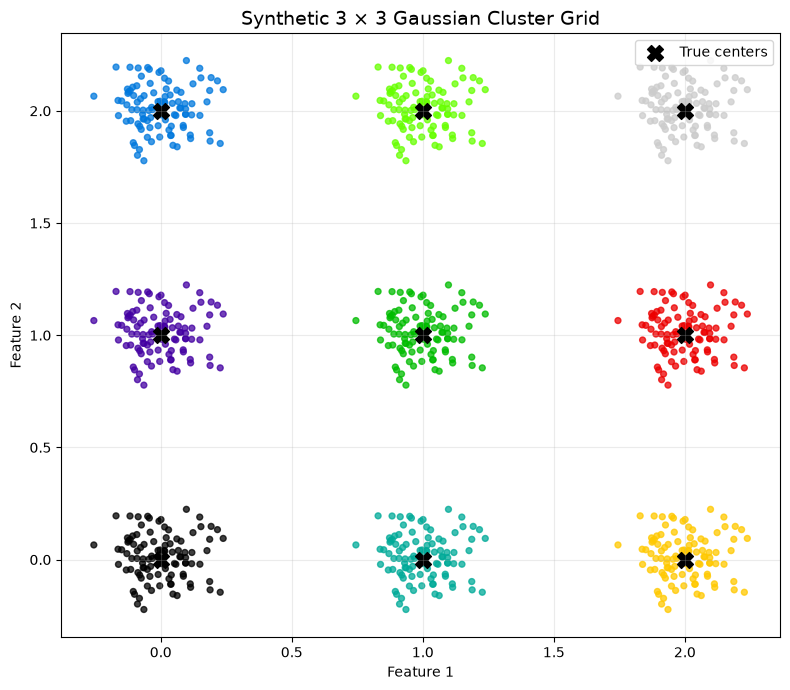

Dataset plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init\data_grid.png


In [6]:
data_plot_path = PLOT_DIR / "data_grid.png"

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    X_demo[:, 0],
    X_demo[:, 1],
    c=y_demo,
    cmap="nipy_spectral",
    s=18,
    alpha=0.75,
)

ax.scatter(
    true_centers[:, 0],
    true_centers[:, 1],
    marker="X",
    s=130,
    c="black",
    label="True centers",
)

ax.set_title(
    "Synthetic 3 × 3 Gaussian Cluster Grid",
    fontsize=14,
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    data_plot_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Dataset plot saved to: {data_plot_path}")

##### Explanation :
The plot should show nine compact and clearly separated groups arranged in a `3 × 3` grid.

The black `X` markers represent the true cluster centers used to generate the observations.

This plot is saved as:
```
root_folder/plots/emp_eval_init/data_grid.png
```

### Define the Clustering Configurations

Create the four estimator and initialization combinations used in the empirical comparison.

In [7]:
CASES = [
    {
        "model_class": KMeans,
        "estimator": "KMeans",
        "init": "k-means++",
        "params": {},
        "plot_style": "^-",
    },
    {
        "model_class": KMeans,
        "estimator": "KMeans",
        "init": "random",
        "params": {},
        "plot_style": "o-",
    },
    {
        "model_class": MiniBatchKMeans,
        "estimator": "MiniBatchKMeans",
        "init": "k-means++",
        "params": {
            "max_no_improvement": 3
        },
        "plot_style": "x-",
    },
    {
        "model_class": MiniBatchKMeans,
        "estimator": "MiniBatchKMeans",
        "init": "random",
        "params": {
            "max_no_improvement": 3,
            "init_size": 500,
        },
        "plot_style": "d-",
    },
]

case_table = pd.DataFrame(
    {
        "Estimator": [
            case["estimator"]
            for case in CASES
        ],
        "Initialization": [
            case["init"]
            for case in CASES
        ],
        "Additional_Parameters": [
            str(case["params"])
            for case in CASES
        ],
    }
)

display(case_table)

,Estimator,Initialization,Additional_Parameters
0,KMeans,k-means++,{}
1,KMeans,random,{}
2,MiniBatchKMeans,k-means++,{'max_no_improvement': 3}
3,MiniBatchKMeans,random,"{'max_no_improvement': 3, 'init_size': 500}"


##### Explanation :
The table confirms that two clustering estimators are evaluated:
- Standard KMeans
- MiniBatchKMeans

Each estimator is tested using:
- `k-means++` initialization
- Random initialization

`MiniBatchKMeans` also receives additional parameters that control early stopping and the number of observations used during initialization.

### Create the Evaluation Function

Build a function that repeatedly fits every clustering configuration and records inertia, ARI, and fitting time.

In [8]:
def evaluate_initialization(
    cases=CASES,
    n_init_range=N_INIT_RANGE,
    n_runs=N_RUNS,
):
    """
    Evaluate all estimator and initialization configurations.
    """

    run_records = []

    for case in cases:

        print(
            f"Evaluating {case['estimator']} "
            f"with {case['init']} initialization..."
        )

        for run_id in range(n_runs):

            X, y, _ = make_data(
                random_state=run_id
            )

            for n_init in n_init_range:

                model = case["model_class"](
                    n_clusters=N_CLUSTERS,
                    init=case["init"],
                    n_init=int(n_init),
                    random_state=run_id,
                    **case["params"],
                )

                start_time = perf_counter()

                predicted_labels = model.fit_predict(X)

                fit_time = (
                    perf_counter() - start_time
                )

                ari = adjusted_rand_score(
                    y,
                    predicted_labels,
                )

                run_records.append(
                    {
                        "Estimator": case["estimator"],
                        "Initialization": case["init"],
                        "n_init": int(n_init),
                        "Run": run_id,
                        "Inertia": model.inertia_,
                        "ARI": ari,
                        "Time_sec": fit_time,
                    }
                )

    raw_results = pd.DataFrame(
        run_records
    )

    summary_results = (
        raw_results
        .groupby(
            [
                "Estimator",
                "Initialization",
                "n_init",
            ],
            as_index=False,
        )
        .agg(
            Mean_Inertia=(
                "Inertia",
                "mean",
            ),
            Std_Inertia=(
                "Inertia",
                "std",
            ),
            Mean_ARI=(
                "ARI",
                "mean",
            ),
            Std_ARI=(
                "ARI",
                "std",
            ),
            Mean_Time_sec=(
                "Time_sec",
                "mean",
            ),
            Std_Time_sec=(
                "Time_sec",
                "std",
            ),
        )
    )

    summary_results["Relative_Std_Inertia_pct"] = (
        100
        * summary_results["Std_Inertia"]
        / summary_results["Mean_Inertia"]
    )

    summary_results = summary_results[
        [
            "Estimator",
            "Initialization",
            "n_init",
            "Mean_Inertia",
            "Std_Inertia",
            "Relative_Std_Inertia_pct",
            "Mean_ARI",
            "Std_ARI",
            "Mean_Time_sec",
            "Std_Time_sec",
        ]
    ]

    return raw_results, summary_results

##### Explanation :
For every estimator and initialization strategy, the function:
- Generates five independently randomized datasets.
- Tests five different n_init values.
- Fits the selected clustering model.
- Records the clustering inertia.
- Calculates the Adjusted Rand Index.
- Measures the fitting time.
- Stores the result from every individual run.
- Calculates the mean and standard deviation for every configuration.

The function returns:
- A run-level results table
- A summarized results table

### Run the Empirical Evaluation

Execute the complete experiment across four clustering configurations, five datasets, and five `n_init` values.

In [9]:
raw_results_df, metrics_df = evaluate_initialization()

print("\nEvaluation completed successfully.")

print(
    f"Individual run records : "
    f"{len(raw_results_df):,}"
)

print(
    f"Summary rows           : "
    f"{len(metrics_df):,}"
)

Evaluating KMeans with k-means++ initialization...
Evaluating KMeans with random initialization...
Evaluating MiniBatchKMeans with k-means++ initialization...
Evaluating MiniBatchKMeans with random initialization...

Evaluation completed successfully.
Individual run records : 100
Summary rows           : 20


##### Explanation :
The experiment produces 100 individual model-fitting records:
```
4 clustering configurations
× 5 repeated runs
× 5 n_init values
= 100 individual runs
```
These 100 records are summarized into 20 rows:
```
4 clustering configurations
× 5 n_init values
= 20 summary rows
```

### Display and Save Individual Run Results

Display a sample of the run-level results and save the complete table for later analysis.

In [10]:
raw_display = raw_results_df.copy()

raw_numeric_columns = (
    raw_display
    .select_dtypes(include="number")
    .columns
)

raw_display[raw_numeric_columns] = (
    raw_display[raw_numeric_columns]
    .round(6)
)

print("=" * 100)
print("INDIVIDUAL INITIALIZATION RUNS")
print("=" * 100)

display(
    raw_display.head(20)
)

raw_results_path = (
    RESULTS_DIR / "init_runs.csv"
)

raw_results_df.to_csv(
    raw_results_path,
    index=False,
)

print(
    f"Individual run results saved to: "
    f"{raw_results_path}"
)

INDIVIDUAL INITIALIZATION RUNS


,Estimator,Initialization,n_init,Run,Inertia,ARI,Time_sec
0,KMeans,k-means++,1,0,18.686510,1.0,1.288870
1,KMeans,k-means++,5,0,18.686510,1.0,0.021050
2,KMeans,k-means++,10,0,18.686510,1.0,0.039741
3,KMeans,k-means++,15,0,18.686510,1.0,0.058921
4,KMeans,k-means++,20,0,18.686510,1.0,0.079548
5,KMeans,k-means++,1,1,14.648251,1.0,0.004677
6,KMeans,k-means++,5,1,14.648251,1.0,0.019733
7,KMeans,k-means++,10,1,14.648251,1.0,0.040350
8,KMeans,k-means++,15,1,14.648251,1.0,0.059130
9,KMeans,k-means++,20,1,14.648251,1.0,0.079765


Individual run results saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\init_runs.csv


##### Explanation :
Each row represents one fitted clustering model.

The table includes:
- Estimator name
- Initialization strategy
- `n_init` value
- Run number
- Inertia
- Adjusted Rand Index
- Fitting time

The complete table is saved as:
```
root_folder/results/emp_eval_init/init_runs.csv
```
This run-level file can be used for detailed comparisons between repeated runs.

### Display and Save Summary Metrics

Display the averaged evaluation metrics and save the complete summary table.

In [11]:
metrics_display = metrics_df.copy()

metrics_numeric_columns = (
    metrics_display
    .select_dtypes(include="number")
    .columns
)

metrics_display[metrics_numeric_columns] = (
    metrics_display[metrics_numeric_columns]
    .round(6)
)

print("=" * 110)
print("INITIALIZATION PERFORMANCE SUMMARY")
print("=" * 110)

display(metrics_display)

metrics_path = (
    RESULTS_DIR / "init_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False,
)

print(
    f"Summary metrics saved to: "
    f"{metrics_path}"
)

INITIALIZATION PERFORMANCE SUMMARY


,Estimator,Initialization,n_init,Mean_Inertia,Std_Inertia,Relative_Std_Inertia_pct,Mean_ARI,Std_ARI,Mean_Time_sec,Std_Time_sec
0,KMeans,k-means++,1,17.521097,2.413742,13.776204,1.000000,0.000000,0.261374,0.574387
1,KMeans,k-means++,5,17.521097,2.413742,13.776204,1.000000,0.000000,0.020356,0.000611
2,KMeans,k-means++,10,17.521097,2.413742,13.776204,1.000000,0.000000,0.040350,0.000931
3,KMeans,k-means++,15,17.521097,2.413742,13.776204,1.000000,0.000000,0.059792,0.001140
4,KMeans,k-means++,20,17.521097,2.413742,13.776204,1.000000,0.000000,0.079726,0.000946
5,KMeans,random,1,96.354091,28.500313,29.578727,0.780836,0.066179,0.004415,0.000420
6,KMeans,random,5,46.908437,26.977189,57.510313,0.912504,0.079898,0.019263,0.000843
7,KMeans,random,10,27.404700,20.573503,75.072899,0.971223,0.064347,0.038646,0.001024
8,KMeans,random,15,17.521097,2.413742,13.776204,1.000000,0.000000,0.058020,0.001058
9,KMeans,random,20,17.521097,2.413742,13.776204,1.000000,0.000000,0.076069,0.001322


Summary metrics saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\init_metrics.csv


##### Explanation :
The summarized table reports the following measurements for every configuration:
- Mean inertia
- Standard deviation of inertia
- Relative standard deviation of inertia
- Mean Adjusted Rand Index
- Standard deviation of Adjusted Rand Index
- Mean fitting time
- Standard deviation of fitting time

Lower inertia represents more compact clusters.

Higher ARI represents better agreement between the predicted clusters and the known true clusters.

Lower standard deviation indicates that a configuration is more stable across repeated datasets.

The summary table is saved as:
```
root_folder/results/emp_eval_init/init_metrics.csv
```

### Find the Lowest-Inertia Setting for Each Case

Identify the tested `n_init` value that produced the lowest mean inertia for every estimator and initialization strategy.

In [12]:
best_indices = (
    metrics_df
    .groupby(
        [
            "Estimator",
            "Initialization",
        ]
    )["Mean_Inertia"]
    .idxmin()
)

best_cases_df = (
    metrics_df
    .loc[best_indices]
    .sort_values(
        [
            "Estimator",
            "Initialization",
        ]
    )
    .reset_index(drop=True)
)

best_cases_display = (
    best_cases_df.copy()
)

best_numeric_columns = (
    best_cases_display
    .select_dtypes(include="number")
    .columns
)

best_cases_display[best_numeric_columns] = (
    best_cases_display[best_numeric_columns]
    .round(6)
)

print("=" * 110)
print(
    "LOWEST MEAN INERTIA FOR EACH "
    "ESTIMATOR AND INITIALIZATION"
)
print("=" * 110)

display(best_cases_display)

best_cases_path = (
    RESULTS_DIR / "best_cases.csv"
)

best_cases_df.to_csv(
    best_cases_path,
    index=False,
)

print(
    f"Best-case results saved to: "
    f"{best_cases_path}"
)

LOWEST MEAN INERTIA FOR EACH ESTIMATOR AND INITIALIZATION


,Estimator,Initialization,n_init,Mean_Inertia,Std_Inertia,Relative_Std_Inertia_pct,Mean_ARI,Std_ARI,Mean_Time_sec,Std_Time_sec
0,KMeans,k-means++,5,17.521097,2.413742,13.776204,1.000000,0.000000,0.020356,0.000611
1,KMeans,random,15,17.521097,2.413742,13.776204,1.000000,0.000000,0.058020,0.001058
2,MiniBatchKMeans,k-means++,1,17.550391,2.424120,13.812340,1.000000,0.000000,0.030452,0.003988
3,MiniBatchKMeans,random,5,48.318827,26.740306,55.341381,0.909776,0.082432,0.075139,0.040903


Best-case results saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\best_cases.csv


##### Explanation :
This code groups the summarized results by estimator and initialization strategy.

Within each group, it finds the `n_init` value that produced the lowest average inertia.

The resulting table contains the strongest tested configuration for:

- `KMeans` with `k-means++`
- `KMeans` with random initialization
- `MiniBatchKMeans` with `k-means++`
- `MiniBatchKMeans` with random initialization

The results are saved as:
```
root_folder/results/emp_eval_init/best_cases.csv
```

### Plot Mean Inertia

Compare clustering compactness across the tested `n_init` values. Error bars show the standard deviation across the five repeated datasets.

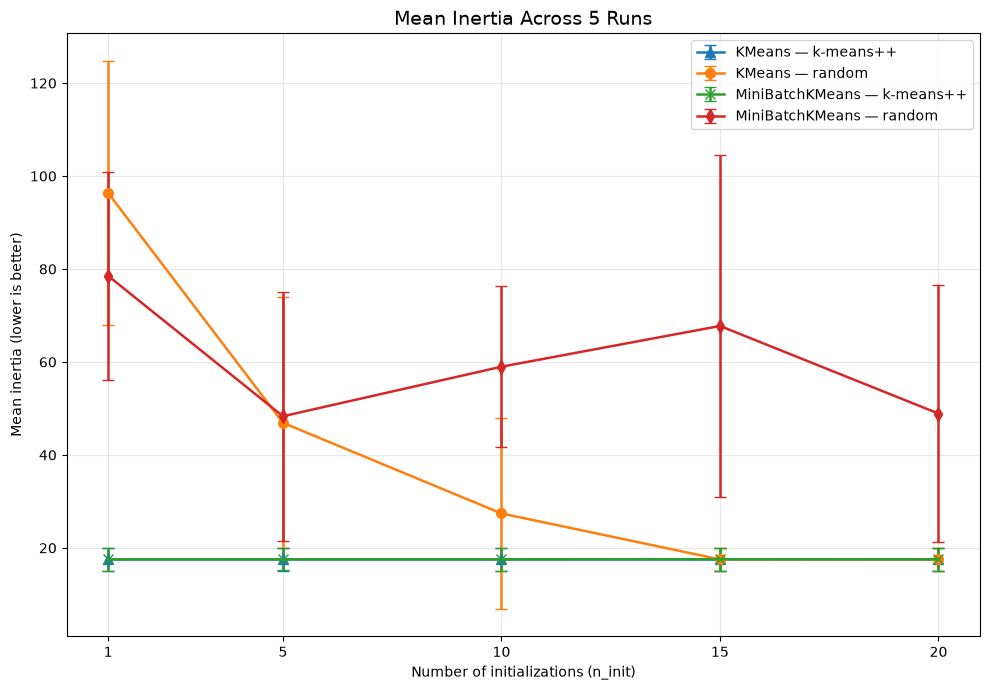

Inertia plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init\inertia.png


In [13]:
inertia_plot_path = (
    PLOT_DIR / "inertia.png"
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for case in CASES:

    case_results = metrics_df[
        (
            metrics_df["Estimator"]
            == case["estimator"]
        )
        & (
            metrics_df["Initialization"]
            == case["init"]
        )
    ].sort_values("n_init")

    ax.errorbar(
        case_results["n_init"],
        case_results["Mean_Inertia"],
        yerr=case_results["Std_Inertia"],
        fmt=case["plot_style"],
        capsize=4,
        linewidth=1.8,
        markersize=7,
        label=(
            f"{case['estimator']} — "
            f"{case['init']}"
        ),
    )

ax.set_title(
    f"Mean Inertia Across {N_RUNS} Runs",
    fontsize=14,
)

ax.set_xlabel(
    "Number of initializations (n_init)"
)

ax.set_ylabel(
    "Mean inertia (lower is better)"
)

ax.set_xticks(N_INIT_RANGE)

ax.grid(alpha=0.30)
ax.legend()

fig.tight_layout()

fig.savefig(
    inertia_plot_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Inertia plot saved to: "
    f"{inertia_plot_path}"
)

##### Explanation :
The inertia plot compares cluster compactness for the four clustering configurations.

A lower line indicates that observations are located closer to their assigned cluster centers.

Large error bars indicate that the clustering result changes considerably across repeated datasets.

`k-means++` should generally produce lower and more stable inertia when `n_init` is small. Random initialization may require more restarts before reaching a similarly strong clustering result.

The plot is saved as:
```
root_folder/plots/emp_eval_init/inertia.png
```

### Plot the Adjusted Rand Index

Compare how accurately each clustering configuration recovers the known synthetic cluster assignments.

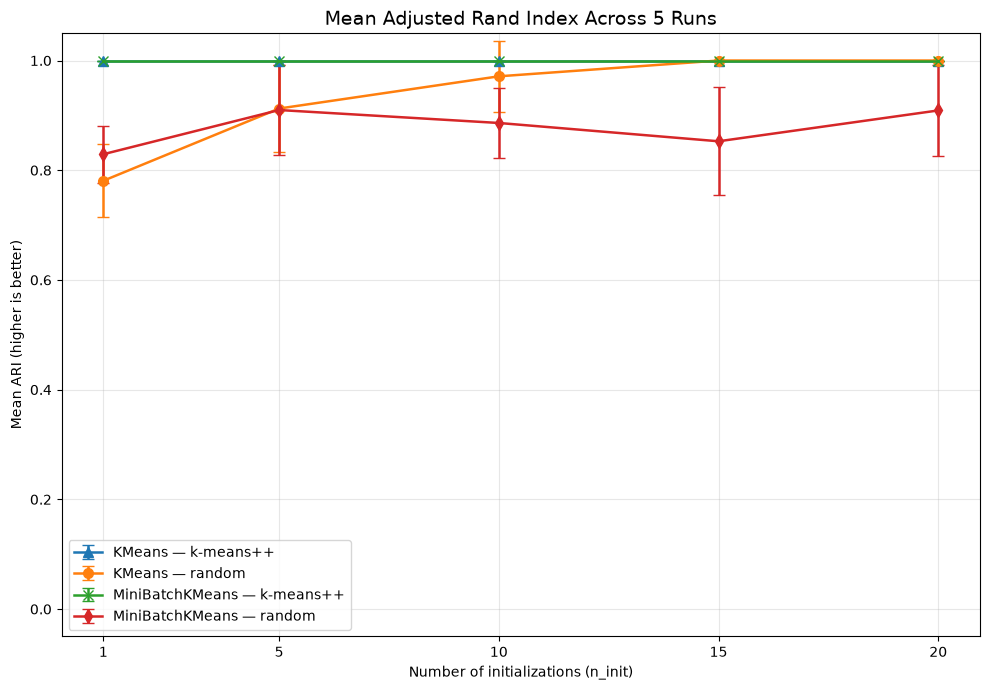

ARI plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init\ari.png


In [14]:
ari_plot_path = (
    PLOT_DIR / "ari.png"
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for case in CASES:

    case_results = metrics_df[
        (
            metrics_df["Estimator"]
            == case["estimator"]
        )
        & (
            metrics_df["Initialization"]
            == case["init"]
        )
    ].sort_values("n_init")

    ax.errorbar(
        case_results["n_init"],
        case_results["Mean_ARI"],
        yerr=case_results["Std_ARI"],
        fmt=case["plot_style"],
        capsize=4,
        linewidth=1.8,
        markersize=7,
        label=(
            f"{case['estimator']} — "
            f"{case['init']}"
        ),
    )

ax.set_title(
    (
        "Mean Adjusted Rand Index "
        f"Across {N_RUNS} Runs"
    ),
    fontsize=14,
)

ax.set_xlabel(
    "Number of initializations (n_init)"
)

ax.set_ylabel(
    "Mean ARI (higher is better)"
)

ax.set_xticks(N_INIT_RANGE)

ax.set_ylim(
    -0.05,
    1.05,
)

ax.grid(alpha=0.30)
ax.legend()

fig.tight_layout()

fig.savefig(
    ari_plot_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"ARI plot saved to: "
    f"{ari_plot_path}"
)

##### Explanation :
The Adjusted Rand Index measures agreement between the predicted cluster labels and the true synthetic cluster labels.

An ARI near `1.0` indicates nearly perfect recovery of the true clusters.

An ARI near `0.0` indicates that the predicted clustering is similar to a random assignment.

Random initialization with a small `n_init` may merge some true clusters or divide one true cluster into multiple groups. Increasing `n_init` gives the model more opportunities to find a better centroid configuration.

The plot is saved as:
```
root_folder/plots/emp_eval_init/ari.png
```

### Plot Computational Time
Measure the computational cost of increasing the number of independent centroid initializations.

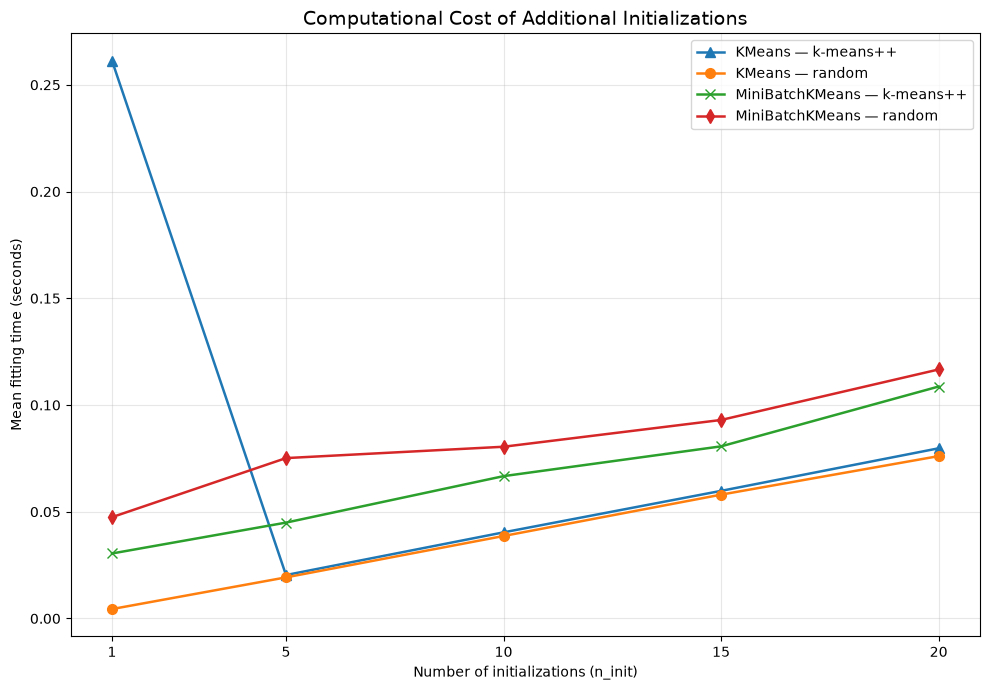

Fitting-time plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init\time.png


In [15]:
time_plot_path = (
    PLOT_DIR / "time.png"
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for case in CASES:

    case_results = metrics_df[
        (
            metrics_df["Estimator"]
            == case["estimator"]
        )
        & (
            metrics_df["Initialization"]
            == case["init"]
        )
    ].sort_values("n_init")

    ax.plot(
        case_results["n_init"],
        case_results["Mean_Time_sec"],
        case["plot_style"],
        linewidth=1.8,
        markersize=7,
        label=(
            f"{case['estimator']} — "
            f"{case['init']}"
        ),
    )

ax.set_title(
    "Computational Cost of Additional Initializations",
    fontsize=14,
)

ax.set_xlabel(
    "Number of initializations (n_init)"
)

ax.set_ylabel(
    "Mean fitting time (seconds)"
)

ax.set_xticks(N_INIT_RANGE)

ax.grid(alpha=0.30)
ax.legend()

fig.tight_layout()

fig.savefig(
    time_plot_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Fitting-time plot saved to: "
    f"{time_plot_path}"
)

##### Explanation :
Fitting time generally increases as `n_init` increases.

For example, when `n_init=20`, the estimator performs up to twenty independent centroid initialization attempts and retains the solution with the lowest inertia.

This improves the likelihood of finding a strong clustering solution but increases computational cost.

Exact timing values may differ between computers, but the increasing computational trend should remain visible.

The plot is saved as:
```
root_folder/plots/emp_eval_init/time.png
```

### Demonstrate a Poor Local Optimum

Fit `MiniBatchKMeans` with random initialization and `n_init=1` to demonstrate how a single weak starting configuration can produce a poor clustering solution.

In [16]:
bad_run_random_state = (
    np.random.RandomState(
        RANDOM_SEED
    )
)

X_bad, y_bad, bad_true_centers = (
    make_data(
        random_state=bad_run_random_state
    )
)

bad_model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    init="random",
    n_init=1,
    random_state=bad_run_random_state,
).fit(X_bad)

bad_ari = adjusted_rand_score(
    y_bad,
    bad_model.labels_,
)

bad_cluster_sizes = np.bincount(
    bad_model.labels_,
    minlength=N_CLUSTERS,
)

print("=" * 80)
print("SINGLE RANDOM INITIALIZATION RESULT")
print("=" * 80)
print("Estimator       : MiniBatchKMeans")
print("Initialization  : random")
print("n_init          : 1")
print(f"Inertia         : {bad_model.inertia_:.6f}")
print(f"ARI             : {bad_ari:.6f}")
print(f"Iterations      : {bad_model.n_iter_}")
print("=" * 80)

SINGLE RANDOM INITIALIZATION RESULT
Estimator       : MiniBatchKMeans
Initialization  : random
n_init          : 1
Inertia         : 117.181291
ARI             : 0.724432
Iterations      : 34


##### Explanation :
This deliberately weak configuration uses only one random initialization.

Because K-Means optimizes a non-convex objective function, the algorithm can converge to a local optimum rather than the best possible solution.

The poor result should have:

- Higher inertia
- Lower ARI
- Incorrectly positioned cluster centers
- Some true groups merged together
- Some true groups unnecessarily divided

This demonstrates why a single random initialization is generally unreliable.

### Save the Poor-Run Results

Store the estimated center coordinates, predicted cluster sizes, and overall poor-run metrics.

In [17]:
bad_centers_df = pd.DataFrame(
    {
        "Cluster": np.arange(
            N_CLUSTERS
        ),
        "Center_X": (
            bad_model
            .cluster_centers_[:, 0]
        ),
        "Center_Y": (
            bad_model
            .cluster_centers_[:, 1]
        ),
        "Cluster_Size": bad_cluster_sizes,
    }
)

bad_centers_display = (
    bad_centers_df.copy()
)

bad_centers_display[
    [
        "Center_X",
        "Center_Y",
    ]
] = (
    bad_centers_display[
        [
            "Center_X",
            "Center_Y",
        ]
    ]
    .round(6)
)

display(bad_centers_display)

bad_centers_path = (
    RESULTS_DIR / "bad_centers.csv"
)

bad_centers_df.to_csv(
    bad_centers_path,
    index=False,
)

bad_run_df = pd.DataFrame(
    [
        {
            "Estimator": "MiniBatchKMeans",
            "Initialization": "random",
            "n_init": 1,
            "Inertia": bad_model.inertia_,
            "ARI": bad_ari,
            "Iterations": bad_model.n_iter_,
        }
    ]
)

bad_run_path = (
    RESULTS_DIR / "bad_run.csv"
)

bad_run_df.to_csv(
    bad_run_path,
    index=False,
)

print(
    f"Center results saved to : "
    f"{bad_centers_path}"
)

print(
    f"Bad-run summary saved to: "
    f"{bad_run_path}"
)

,Cluster,Center_X,Center_Y,Cluster_Size
0,0,1.048465,-0.035580,56
1,1,1.002139,2.002927,100
2,2,0.933893,0.087681,44
3,3,-0.000431,1.508079,200
4,4,1.002405,1.013720,100
5,5,1.978134,0.141293,44
6,6,2.000465,1.522864,197
7,7,0.015138,0.013615,100
8,8,2.017781,-0.063859,59


Center results saved to : C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\bad_centers.csv
Bad-run summary saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\bad_run.csv


##### Explanation :
The first output table contains:

- Predicted cluster number
- Estimated X-coordinate of the center
- Estimated Y-coordinate of the center
- Number of observations assigned to the cluster

Unusually large clusters may indicate that two or more true clusters were incorrectly merged.

Very small clusters or centers located near one another may indicate that one true cluster was unnecessarily divided.

The center-level table is saved as:
```
root_folder/results/emp_eval_init/bad_centers.csv
```
The overall poor-run metrics are saved as:
```
root_folder/results/emp_eval_init/bad_run.csv
```

### Visualize the Poor Local Optimum

Plot the predicted cluster assignments and estimated centers, and compare them with the true grid centers.

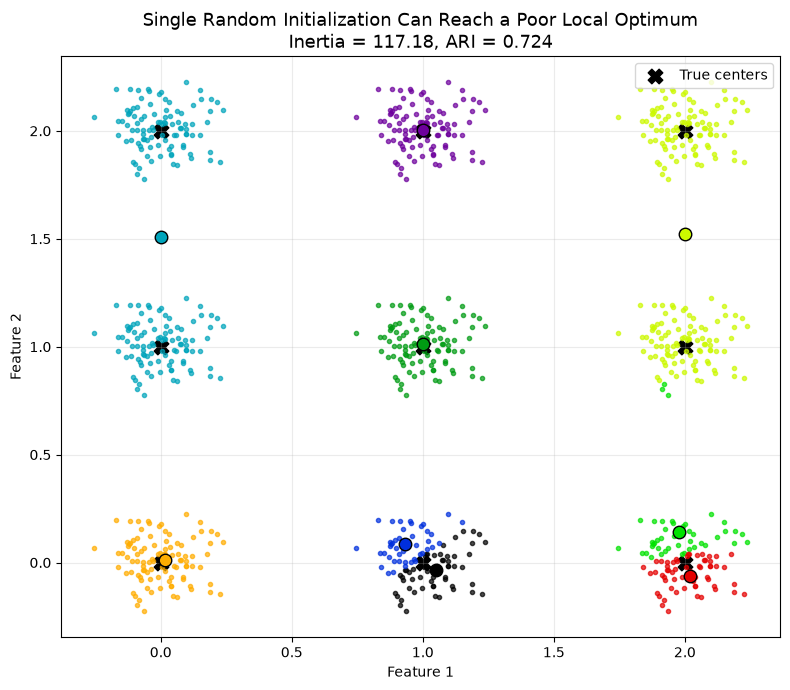

Poor-initialization plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init\bad_init.png


In [18]:
bad_plot_path = (
    PLOT_DIR / "bad_init.png"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for cluster_id in range(N_CLUSTERS):

    members = (
        bad_model.labels_
        == cluster_id
    )

    cluster_color = (
        cm.nipy_spectral(
            float(cluster_id)
            / N_CLUSTERS
        )
    )

    ax.plot(
        X_bad[members, 0],
        X_bad[members, 1],
        ".",
        color=cluster_color,
        alpha=0.70,
    )

    estimated_center = (
        bad_model
        .cluster_centers_[cluster_id]
    )

    ax.plot(
        estimated_center[0],
        estimated_center[1],
        "o",
        markerfacecolor=cluster_color,
        markeredgecolor="black",
        markersize=9,
    )

ax.scatter(
    bad_true_centers[:, 0],
    bad_true_centers[:, 1],
    marker="X",
    s=110,
    c="black",
    label="True centers",
)

ax.set_title(
    (
        "Single Random Initialization Can Reach "
        "a Poor Local Optimum\n"
        f"Inertia = {bad_model.inertia_:.2f}, "
        f"ARI = {bad_ari:.3f}"
    ),
    fontsize=13,
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    bad_plot_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Poor-initialization plot saved to: "
    f"{bad_plot_path}"
)

##### Explanation :
The observations are colored according to the clusters predicted by the poorly initialized `MiniBatchKMeans` model.

The colored circular markers represent the estimated centers.

The black `X` markers represent the true centers.

A poor local optimum can be identified when:

- An estimated center lies between two true groups
- Two estimated centers are placed inside the same true group
- One predicted cluster contains observations from multiple true clusters
- One true cluster is divided across multiple predicted clusters

The plot is saved as:
```
root_folder/plots/emp_eval_init/bad_init.png
```

### Create a Metric Retrieval Function

Create a small helper function for extracting specific values from the summarized results table.

In [19]:
def get_metric(
    estimator,
    initialization,
    n_init,
    column,
):
    """
    Return one metric from the summarized results table.
    """

    selected_row = metrics_df[
        (
            metrics_df["Estimator"]
            == estimator
        )
        & (
            metrics_df["Initialization"]
            == initialization
        )
        & (
            metrics_df["n_init"]
            == n_init
        )
    ]

    return float(
        selected_row.iloc[0][column]
    )

##### Explanation :
This helper function retrieves a specific metric from the summarized results table.

For example, it can retrieve the mean inertia for:
```
Estimator = KMeans
Initialization = random
n_init = 1
```
Using a helper function avoids repeatedly writing the same filtering logic when generating the final text summary.

### Write the Final Results Summary

Create a readable text summary containing the main numerical comparisons and practical interpretation.

In [20]:
# Get the largest n_init value
largest_n_init = int(N_INIT_RANGE.max())

# Calculate metrics before using them in formatted strings
kmeans_pp_inertia_1 = get_metric(
    "KMeans",
    "k-means++",
    1,
    "Mean_Inertia",
)

kmeans_random_inertia_1 = get_metric(
    "KMeans",
    "random",
    1,
    "Mean_Inertia",
)

kmeans_random_inertia_max = get_metric(
    "KMeans",
    "random",
    largest_n_init,
    "Mean_Inertia",
)

# Create the summary
summary_lines = [
    "EMPIRICAL EVALUATION OF K-MEANS INITIALIZATION",
    "=" * 52,
    (
        f"Dataset: {N_CLUSTERS} well-separated "
        f"Gaussian clusters in a "
        f"{GRID_SIZE} x {GRID_SIZE} grid"
    ),
    (
        f"Samples: "
        f"{N_CLUSTERS * N_SAMPLES_PER_CENTER}"
    ),
    (
        f"Independent runs per setting: "
        f"{N_RUNS}"
    ),
    (
        f"n_init values: "
        f"{N_INIT_RANGE.tolist()}"
    ),
    "",
    "Key numerical comparisons:",
    (
        "- KMeans, n_init=1, k-means++ "
        f"mean inertia: {kmeans_pp_inertia_1:.4f}"
    ),
    (
        "- KMeans, n_init=1, random "
        f"mean inertia: {kmeans_random_inertia_1:.4f}"
    ),
    (
        f"- KMeans, n_init={largest_n_init}, "
        f"random mean inertia: "
        f"{kmeans_random_inertia_max:.4f}"
    ),
    (
        "- Bad MiniBatchKMeans run inertia: "
        f"{bad_model.inertia_:.4f}"
    ),
    (
        "- Bad MiniBatchKMeans run ARI: "
        f"{bad_ari:.4f}"
    ),
    "",
    "Interpretation:",
    (
        "- Lower inertia means observations are "
        "closer to their assigned centers."
    ),
    (
        "- k-means++ generally reaches a strong "
        "solution with fewer restarts."
    ),
    (
        "- Random initialization is more vulnerable "
        "when n_init is small."
    ),
    (
        "- Increasing n_init trades more computation "
        "for more robust convergence."
    ),
    (
        "- MiniBatchKMeans is efficient but adds "
        "approximation variability."
    ),
]

# Convert the list into a single text block
summary_text = "\n".join(summary_lines)

# Define the output file path
summary_path = RESULTS_DIR / "summary.txt"

# Save the summary
summary_path.write_text(
    summary_text,
    encoding="utf-8",
)

# Display the summary
print(summary_text)

print(
    f"\nSummary saved to: "
    f"{summary_path}"
)

EMPIRICAL EVALUATION OF K-MEANS INITIALIZATION
Dataset: 9 well-separated Gaussian clusters in a 3 x 3 grid
Samples: 900
Independent runs per setting: 5
n_init values: [1, 5, 10, 15, 20]

Key numerical comparisons:
- KMeans, n_init=1, k-means++ mean inertia: 17.5211
- KMeans, n_init=1, random mean inertia: 96.3541
- KMeans, n_init=20, random mean inertia: 17.5211
- Bad MiniBatchKMeans run inertia: 117.1813
- Bad MiniBatchKMeans run ARI: 0.7244

Interpretation:
- Lower inertia means observations are closer to their assigned centers.
- k-means++ generally reaches a strong solution with fewer restarts.
- Random initialization is more vulnerable when n_init is small.
- Increasing n_init trades more computation for more robust convergence.
- MiniBatchKMeans is efficient but adds approximation variability.

Summary saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init\summary.txt


##### Explanation :
The generated summary automatically includes important numerical results from the completed experiment.

The main interpretation is that `k-means++` usually reaches a strong clustering solution with fewer restarts.

Random initialization is more sensitive to the initial centroid positions and may require a larger `n_init` value to achieve a similarly strong result.

The summary is saved as:
```
root_folder/results/emp_eval_init/summary.txt
```

### Main Findings
#### K-Means++ initialization
`k-means++` generally produces a strong solution even when `n_init` is small because it attempts to spread the initial centers across the feature space.

This reduces the probability that multiple initial centers will be placed inside the same natural cluster.

#### Random initialization

Random initialization can produce high inertia and lower ARI when `n_init` is small.

Increasing `n_init` gives the estimator more opportunities to find a better starting configuration.

However, the additional initialization attempts increase computational cost.

#### MiniBatch K-Means

MiniBatchKMeans updates the cluster centers using small subsets of observations rather than the complete dataset during every update.

This can provide substantial computational savings for large datasets.

However, because it uses approximate updates, its clustering results may have slightly more variability than standard K-Means.

#### Practical conclusion

For most practical K-Means analyses, k-means++ should be preferred over purely random initialization.

Multiple initializations are still recommended when clustering stability is important.

A single random initialization should generally be avoided because it can converge to a poor local optimum.

### Verify All Saved Outputs
List every plot and result file produced by the notebook and confirm that execution completed successfully.

In [21]:
plot_files = sorted(
    PLOT_DIR.glob("*")
)

result_files = sorted(
    RESULTS_DIR.glob("*")
)

print("=" * 80)
print("SAVED PLOTS")
print("=" * 80)

for file_path in plot_files:
    print(f"- {file_path.name}")

print("\n" + "=" * 80)
print("SAVED RESULTS")
print("=" * 80)

for file_path in result_files:
    print(f"- {file_path.name}")

print("\n" + "=" * 80)
print("NOTEBOOK EXECUTION COMPLETED")
print("=" * 80)

print(
    f"Number of plots saved  : "
    f"{len(plot_files)}"
)

print(
    f"Number of result files : "
    f"{len(result_files)}"
)

print(
    f"Plot folder            : "
    f"{PLOT_DIR}"
)

print(
    f"Results folder         : "
    f"{RESULTS_DIR}"
)

print("=" * 80)

SAVED PLOTS
- ari.png
- bad_init.png
- data_grid.png
- inertia.png
- time.png

SAVED RESULTS
- bad_centers.csv
- bad_run.csv
- best_cases.csv
- init_metrics.csv
- init_runs.csv
- summary.txt

NOTEBOOK EXECUTION COMPLETED
Number of plots saved  : 5
Number of result files : 6
Plot folder            : C:\Users\samsa\Documents\Capstone Project\Project\plots\emp_eval_init
Results folder         : C:\Users\samsa\Documents\Capstone Project\Project\results\emp_eval_init
